<a href="https://www.kaggle.com/code/aamir28/impact-of-ai-on-students?scriptVersionId=331213625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0c1222;border-radius:14px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #1e2d4a;">

  <div style="background:linear-gradient(135deg,#1e3a5f 0%,#2d4a7a 100%);padding:30px 40px;">
    <div style="font-size:0.65rem;letter-spacing:4px;color:#93c5fd;font-weight:700;margin-bottom:8px;">INSTITUTIONAL RESEARCH BRIEF · OFFICE OF ACADEMIC AFFAIRS</div>
    <h1 style="margin:0;font-size:2rem;font-weight:900;color:#fff;">🎓 Generative AI in the Classroom: Measuring the Real Impact</h1>
    <p style="margin:10px 0 0;color:#cbd5e1;font-size:0.85rem;max-width:600px;line-height:1.75;">50,000 students surveyed across 5 majors. Does heavier GenAI use actually raise GPA — or does it trade short-term grades for skill erosion and exam anxiety? We test the headline claim directly against the data.</p>
  </div>

  <!-- Headline finding banner -->
  <div style="padding:18px 40px;background:#0f1830;border-bottom:1px solid #1e2d4a;">
    <div style="background:#15203d;border-left:4px solid #f59e0b;border-radius:0 8px 8px 0;padding:14px 20px;">
      <span style="color:#f59e0b;font-weight:700;font-size:0.82rem;">📊 HEADLINE FINDING — </span>
      <span style="color:#cbd5e1;font-size:0.82rem;">Weekly GenAI hours show almost no correlation with GPA change (r=−0.046) — but a strong
      correlation with perceived AI dependency (r=0.665), exam anxiety (r=0.269), and reduced skill retention (r=−0.118).
      Traditional study hours remain a far stronger GPA predictor (r=0.376) than GenAI usage. The skill with which
      students use AI — not how much they use it — is what actually predicts academic gains.</span>
    </div>
  </div>

  <!-- Metrics strip -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#0c1222;">
    <div style="padding:16px 18px;border-right:1px solid #1e2d4a;text-align:center;">
      <div style="font-size:0.6rem;color:#93c5fd;letter-spacing:1px;margin-bottom:5px;">STUDENTS SURVEYED</div>
      <div style="font-size:1.35rem;font-weight:800;color:#fff;">50,000</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #1e2d4a;text-align:center;">
      <div style="font-size:0.6rem;color:#93c5fd;letter-spacing:1px;margin-bottom:5px;">MEAN GPA CHANGE</div>
      <div style="font-size:1.35rem;font-weight:800;color:#34d399;">+0.203</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #1e2d4a;text-align:center;">
      <div style="font-size:0.6rem;color:#93c5fd;letter-spacing:1px;margin-bottom:5px;">AVG WEEKLY AI HOURS</div>
      <div style="font-size:1.35rem;font-weight:800;color:#fff;">8.4 hrs</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #1e2d4a;text-align:center;">
      <div style="font-size:0.6rem;color:#93c5fd;letter-spacing:1px;margin-bottom:5px;">HIGH BURNOUT RISK</div>
      <div style="font-size:1.35rem;font-weight:800;color:#f87171;">25.0%</div>
    </div>
    <div style="padding:16px 18px;text-align:center;">
      <div style="font-size:0.6rem;color:#93c5fd;letter-spacing:1px;margin-bottom:5px;">PAID SUBSCRIBERS</div>
      <div style="font-size:1.35rem;font-weight:800;color:#fff;">42.3%</div>
    </div>
  </div>

  <div style="background:#0f1830;padding:9px 40px;border-top:1px solid #1e2d4a;text-align:right;">
    <span style="font-size:0.68rem;color:#3a4a6e;">Author: Muhammad Aamir · AI Student Impact Study · Kaggle Notebook</span>
  </div>
</div>


## 🎓 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Sample Composition](#2)
3. [Feature Engineering](#3)
4. [The Core Claim — Does AI Usage Predict GPA Gains?](#4)
5. [Skill Matters More Than Hours](#5)
6. [The Substitution Effect — AI Hours vs Study Hours](#6)
7. [The Hidden Costs — Dependency, Anxiety & Burnout](#7)
8. [Use Case Matters — Debugging vs Direct Answers](#8)
9. [Institutional Policy — Does Banning AI Help?](#9)
10. [Correlation Heatmap](#10)
11. [ML — Predicting GPA Change](#11)
12. [Key Takeaways for Policy](#12)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

BG, PANEL, GRID = '#0c1222','#0f1830','#1e2d4a'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#93a5c5','axes.titlecolor':'#fff','axes.titlesize':13,
    'xtick.color':'#5a6b8a','ytick.color':'#5a6b8a','text.color':'#93a5c5',
    'grid.color':'#141d33','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

BLUE   = '#3b82f6'
GREEN  = '#34d399'
AMBER  = '#f59e0b'
RED    = '#f87171'
PURPLE = '#a78bfa'
GRAY   = '#94a3b8'
POLICY_PAL = {'Strict_Ban':RED, 'Allowed_With_Citation':AMBER, 'Actively_Encouraged':GREEN}
SKILL_PAL  = {'Beginner':RED, 'Intermediate':AMBER, 'Advanced':GREEN}
BURNOUT_PAL = {'Low':GREEN, 'Medium':AMBER, 'High':RED}
CMAP_BA = LinearSegmentedColormap.from_list('ba', [RED, BG, GREEN])
print('✅  Institutional research theme loaded. 50,000 student records ready.')


✅  Institutional research theme loaded. 50,000 student records ready.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv')
print(f'Shape: {df.shape}')
df.head(8)

Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium


## 2. EDA & Sample Composition <a id='2'></a>


In [3]:
print('Nulls:', df.isnull().sum().sum())
print(df.describe().round(2).iloc[:3])


Nulls: 0
       Student_ID  Pre_Semester_GPA  Weekly_GenAI_Hours  Tool_Diversity  \
count     50000.0          50000.00            50000.00        50000.00   
mean     125000.5              3.15                8.43            2.80   
std       14433.9              0.48                8.27            1.19   

       Traditional_Study_Hours  Perceived_AI_Dependency  \
count                 50000.00                 50000.00   
mean                     11.21                     3.51   
std                       5.16                     1.82   

       Anxiety_Level_During_Exams  Post_Semester_GPA  Skill_Retention_Score  
count                    50000.00           50000.00               50000.00  
mean                         4.27               3.35                  75.80  
std                          2.14               0.50                  13.28  


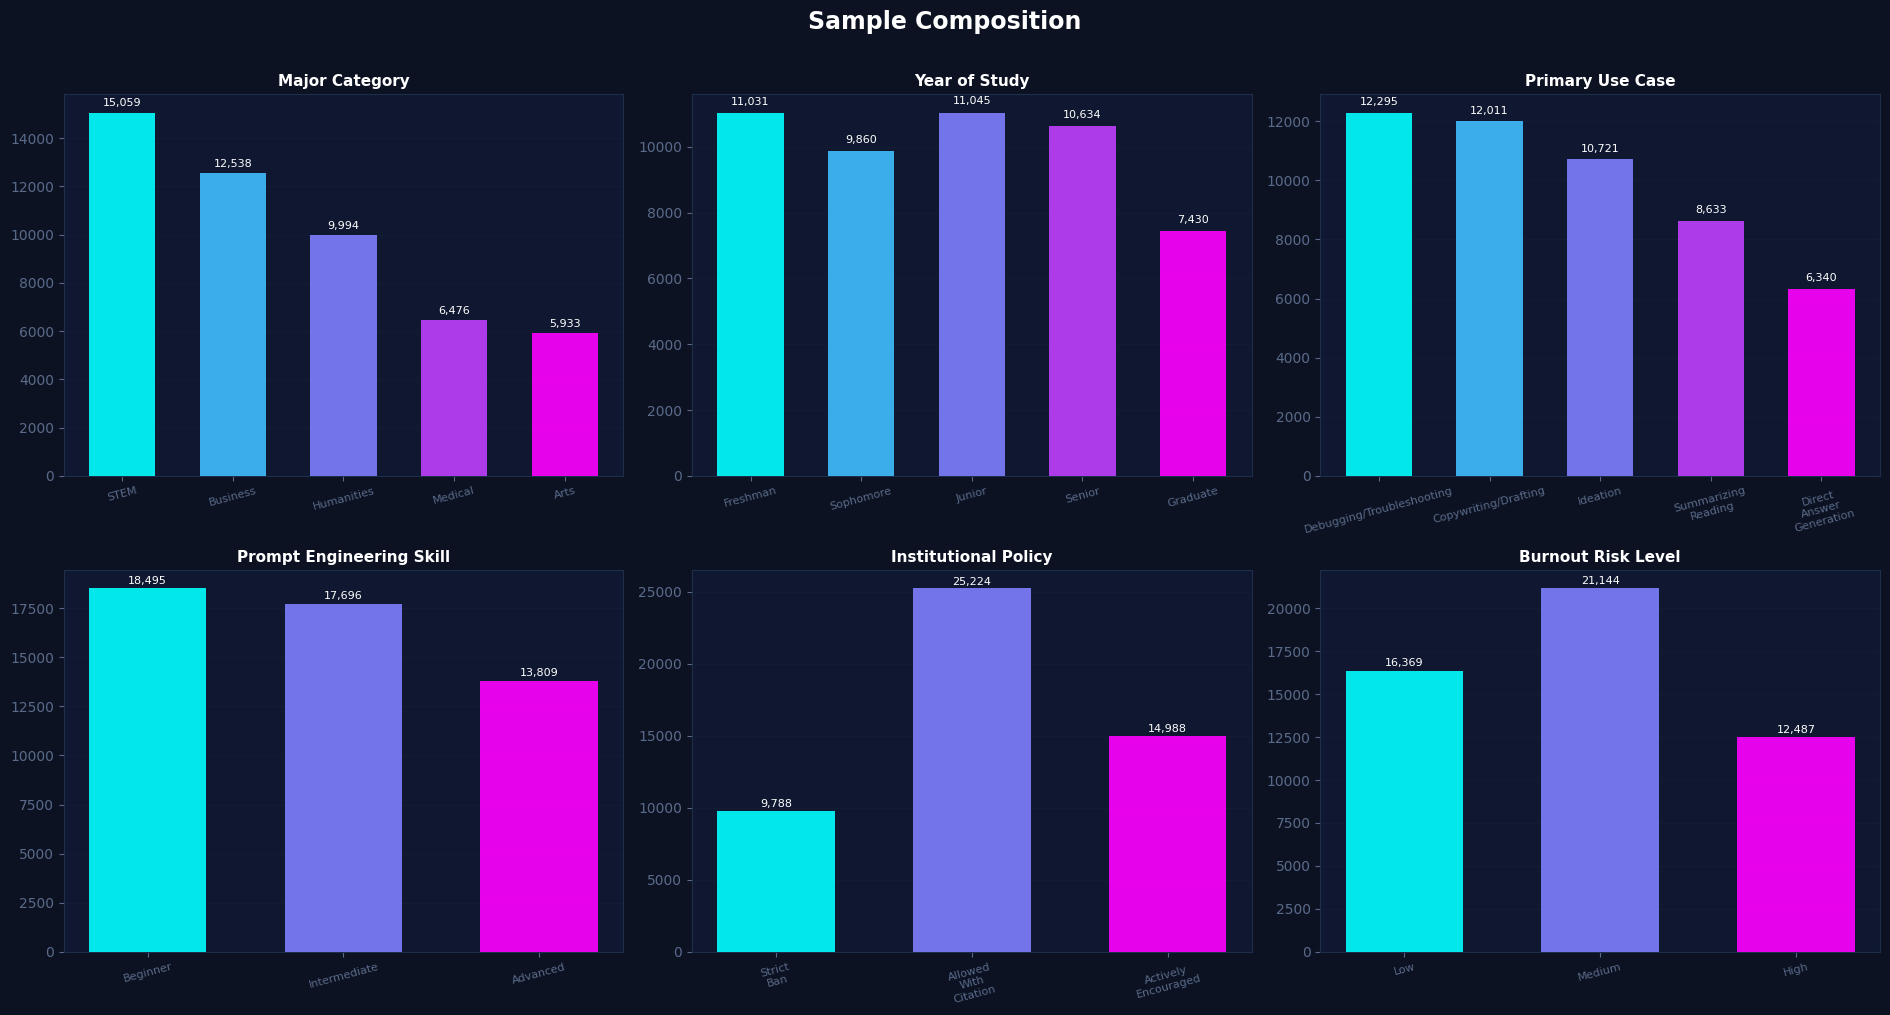

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Sample Composition', fontsize=17, fontweight='bold', color='white', y=1.01)

cats = [
    ('Major_Category', None, 'Major Category'),
    ('Year_of_Study', ['Freshman','Sophomore','Junior','Senior','Graduate'], 'Year of Study'),
    ('Primary_Use_Case', None, 'Primary Use Case'),
    ('Prompt_Engineering_Skill', ['Beginner','Intermediate','Advanced'], 'Prompt Engineering Skill'),
    ('Institutional_Policy', list(POLICY_PAL.keys()), 'Institutional Policy'),
    ('Burnout_Risk_Level', ['Low','Medium','High'], 'Burnout Risk Level'),
]
for ax, (col, order, title) in zip(axes.flat, cats):
    vc = df[col].value_counts()
    if order: vc = vc.reindex(order)
    bar_cols = [plt.cm.cool(i/max(len(vc)-1,1)) for i in range(len(vc))]
    bars = ax.bar(range(len(vc)), vc.values, color=bar_cols, width=0.6, zorder=3, alpha=0.9)
    ax.set_xticks(range(len(vc))); ax.set_xticklabels([str(l).replace('_','\n') for l in vc.index], fontsize=8, rotation=15)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+250, f'{v:,}', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('01_composition.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
df['gpa_change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']
df['skill_enc'] = df['Prompt_Engineering_Skill'].map({'Beginner':0,'Intermediate':1,'Advanced':2})
df['policy_enc'] = df['Institutional_Policy'].map({'Strict_Ban':0,'Allowed_With_Citation':1,'Actively_Encouraged':2})
df['burnout_enc'] = df['Burnout_Risk_Level'].map({'Low':0,'Medium':1,'High':2})
df['paid_enc'] = df['Paid_Subscription'].astype(int)

# AI hours bands
df['ai_hours_band'] = pd.cut(df['Weekly_GenAI_Hours'], bins=[0,5,10,15,20,40],
                              labels=['<5h','5-10h','10-15h','15-20h','20h+'])

# Improved vs declined flag
df['gpa_improved'] = (df['gpa_change'] > 0).astype(int)

print('Engineered: gpa_change, skill_enc, policy_enc, burnout_enc, paid_enc, ai_hours_band, gpa_improved')
print(f'\nStudents who improved GPA: {df["gpa_improved"].sum():,} ({df["gpa_improved"].mean()*100:.1f}%)')


Engineered: gpa_change, skill_enc, policy_enc, burnout_enc, paid_enc, ai_hours_band, gpa_improved

Students who improved GPA: 43,759 (87.5%)


## 4. The Core Claim — Does AI Usage Predict GPA Gains? <a id='4'></a>


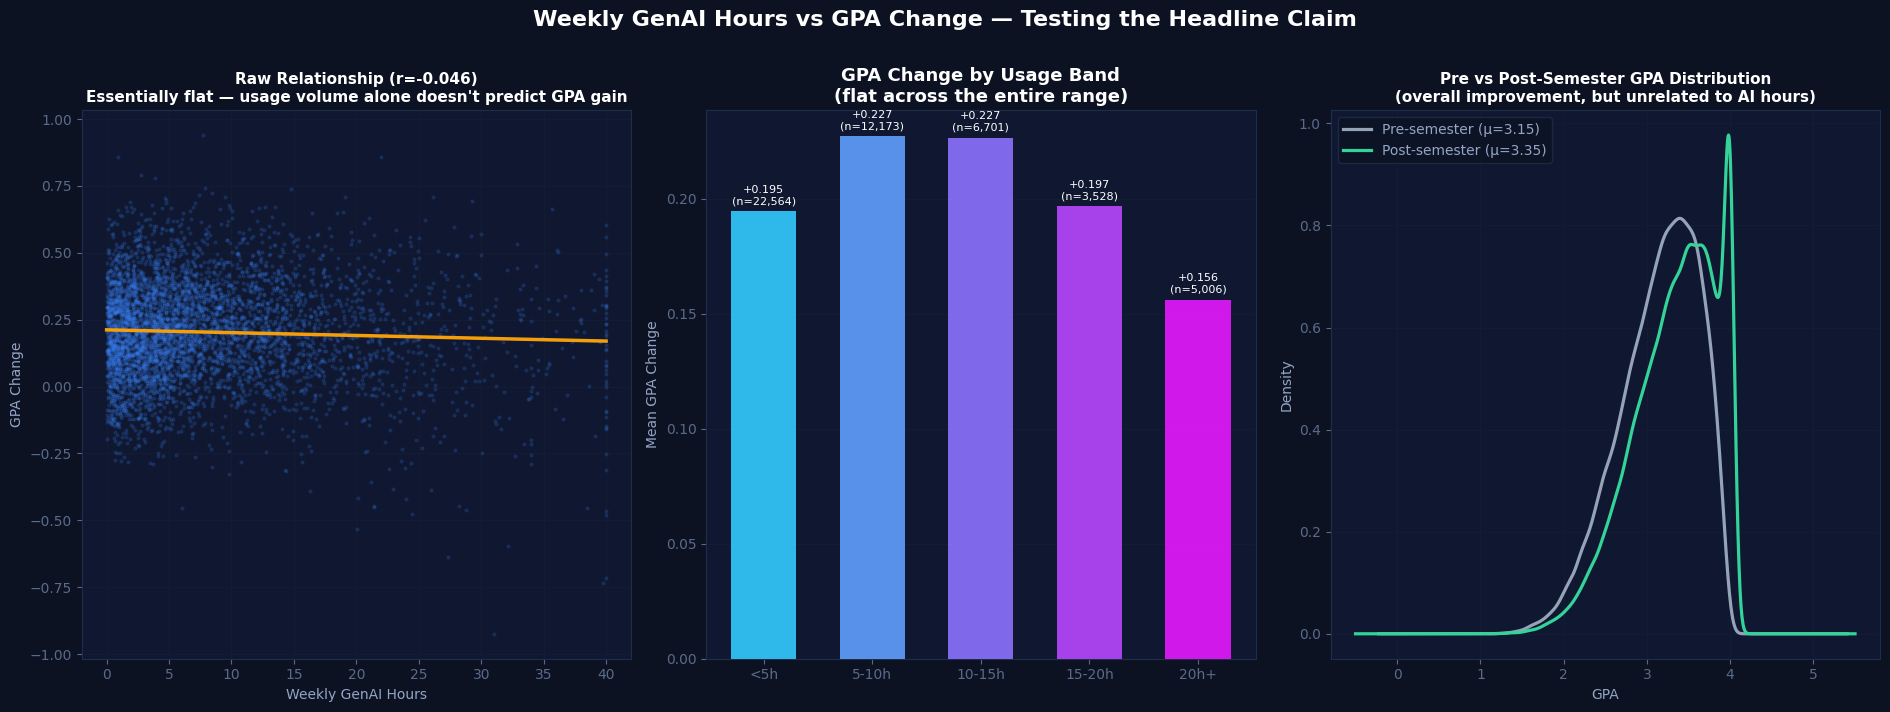

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Weekly GenAI Hours vs GPA Change — Testing the Headline Claim',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Scatter with regression (sampled for visual clarity)
ax = axes[0]
sample = df.sample(5000, random_state=42)
ax.scatter(sample['Weekly_GenAI_Hours'], sample['gpa_change'], color=BLUE, s=4, alpha=0.15, zorder=3)
m, b, r, p, _ = stats.linregress(df['Weekly_GenAI_Hours'], df['gpa_change'])
xr = np.linspace(0, 40, 80)
ax.plot(xr, m*xr+b, color=AMBER, lw=2.5, zorder=5)
ax.set_xlabel('Weekly GenAI Hours'); ax.set_ylabel('GPA Change')
ax.set_title(f'Raw Relationship (r={r:.3f})\nEssentially flat — usage volume alone doesn\'t predict GPA gain', fontweight='bold', fontsize=11)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Mean GPA change by AI hours band
ax = axes[1]
band_order = ['<5h','5-10h','10-15h','15-20h','20h+']
band_means = df.groupby('ai_hours_band', observed=True)['gpa_change'].mean().reindex(band_order)
band_ns    = df.groupby('ai_hours_band', observed=True)['gpa_change'].count().reindex(band_order)
bars = ax.bar(range(5), band_means.values, color=plt.cm.cool(np.linspace(0.2,0.9,5)), width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(5)); ax.set_xticklabels(band_order, fontsize=10)
ax.set_ylabel('Mean GPA Change')
ax.set_title('GPA Change by Usage Band\n(flat across the entire range)', fontweight='bold')
for bar, v, n in zip(bars, band_means.values, band_ns.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:+.3f}\n(n={n:,})', ha='center', fontsize=8, color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Pre vs Post GPA distribution
ax = axes[2]
df['Pre_Semester_GPA'].plot.kde(ax=ax, color=GRAY, lw=2.3, label=f'Pre-semester (μ={df["Pre_Semester_GPA"].mean():.2f})')
df['Post_Semester_GPA'].plot.kde(ax=ax, color=GREEN, lw=2.3, label=f'Post-semester (μ={df["Post_Semester_GPA"].mean():.2f})')
ax.set_xlabel('GPA'); ax.set_ylabel('Density')
ax.set_title('Pre vs Post-Semester GPA Distribution\n(overall improvement, but unrelated to AI hours)', fontweight='bold', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('02_core_claim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Skill Matters More Than Hours <a id='5'></a>


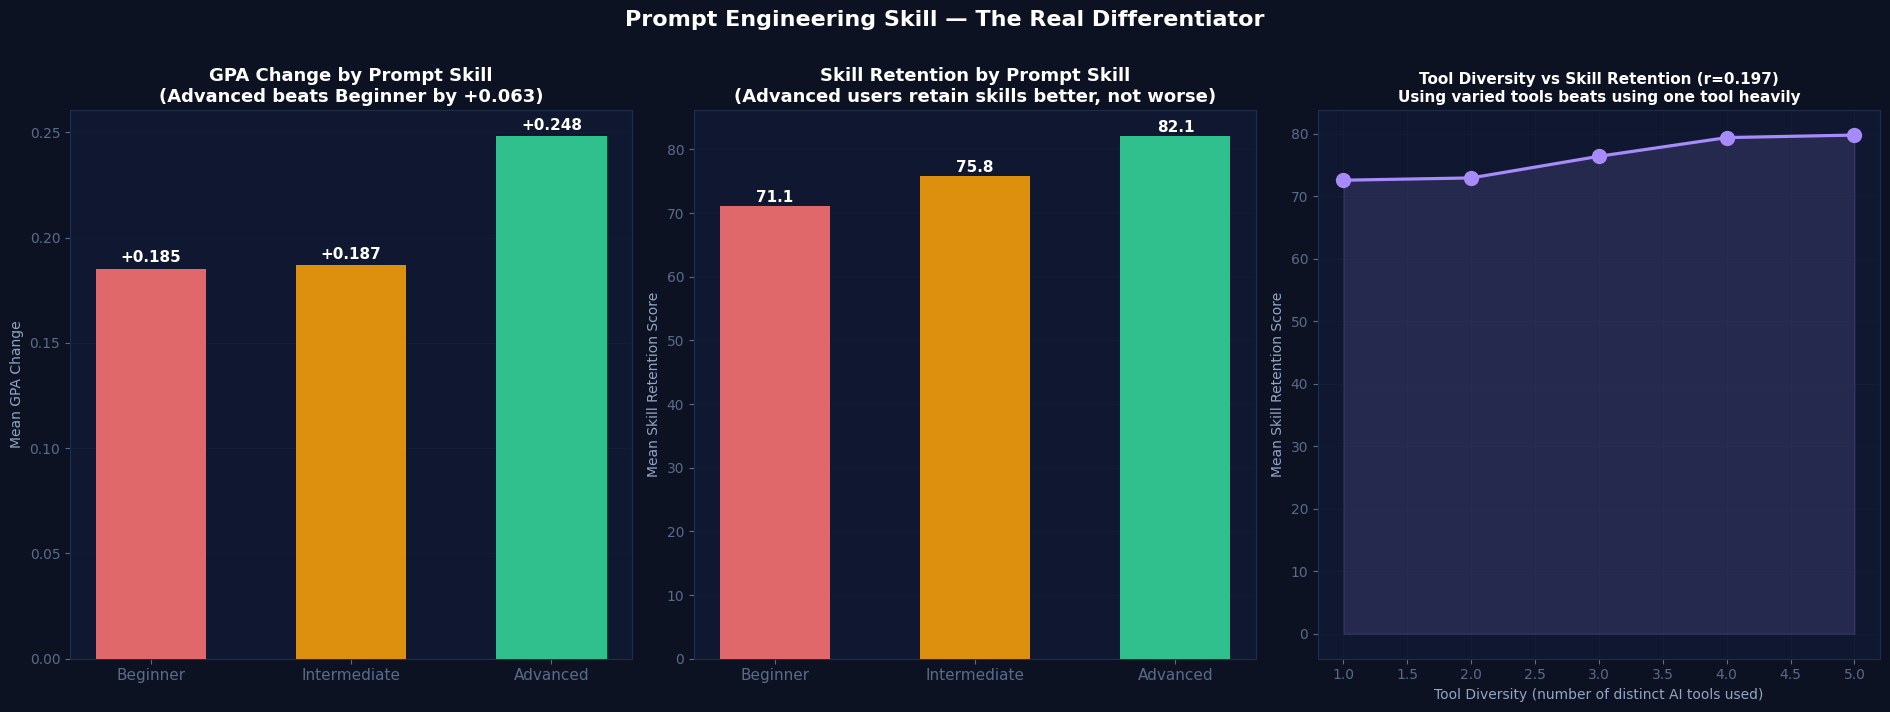

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Prompt Engineering Skill — The Real Differentiator', fontsize=16, fontweight='bold', color='white', y=1.01)

skill_order = ['Beginner','Intermediate','Advanced']

# 1. GPA change by skill
ax = axes[0]
skill_gpa = df.groupby('Prompt_Engineering_Skill')['gpa_change'].mean().reindex(skill_order)
bars = ax.bar(range(3), skill_gpa.values, color=[SKILL_PAL[s] for s in skill_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels(skill_order, fontsize=11)
ax.set_ylabel('Mean GPA Change')
ax.set_title('GPA Change by Prompt Skill\n(Advanced beats Beginner by +0.063)', fontweight='bold')
for bar, v in zip(bars, skill_gpa.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:+.3f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Skill retention by skill level
ax = axes[1]
skill_ret = df.groupby('Prompt_Engineering_Skill')['Skill_Retention_Score'].mean().reindex(skill_order)
bars2 = ax.bar(range(3), skill_ret.values, color=[SKILL_PAL[s] for s in skill_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels(skill_order, fontsize=11)
ax.set_ylabel('Mean Skill Retention Score')
ax.set_title('Skill Retention by Prompt Skill\n(Advanced users retain skills better, not worse)', fontweight='bold')
for bar, v in zip(bars2, skill_ret.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Tool diversity vs skill retention scatter
ax = axes[2]
td_ret = df.groupby('Tool_Diversity')['Skill_Retention_Score'].mean()
ax.plot(td_ret.index, td_ret.values, 'o-', color=PURPLE, lw=2.3, ms=10, zorder=5)
ax.fill_between(td_ret.index, td_ret.values, alpha=0.15, color=PURPLE)
ax.set_xlabel('Tool Diversity (number of distinct AI tools used)'); ax.set_ylabel('Mean Skill Retention Score')
ax.set_title(f'Tool Diversity vs Skill Retention (r={df["Tool_Diversity"].corr(df["Skill_Retention_Score"]):.3f})\nUsing varied tools beats using one tool heavily', fontweight='bold', fontsize=11)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_skill.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. The Substitution Effect — AI Hours vs Study Hours <a id='6'></a>


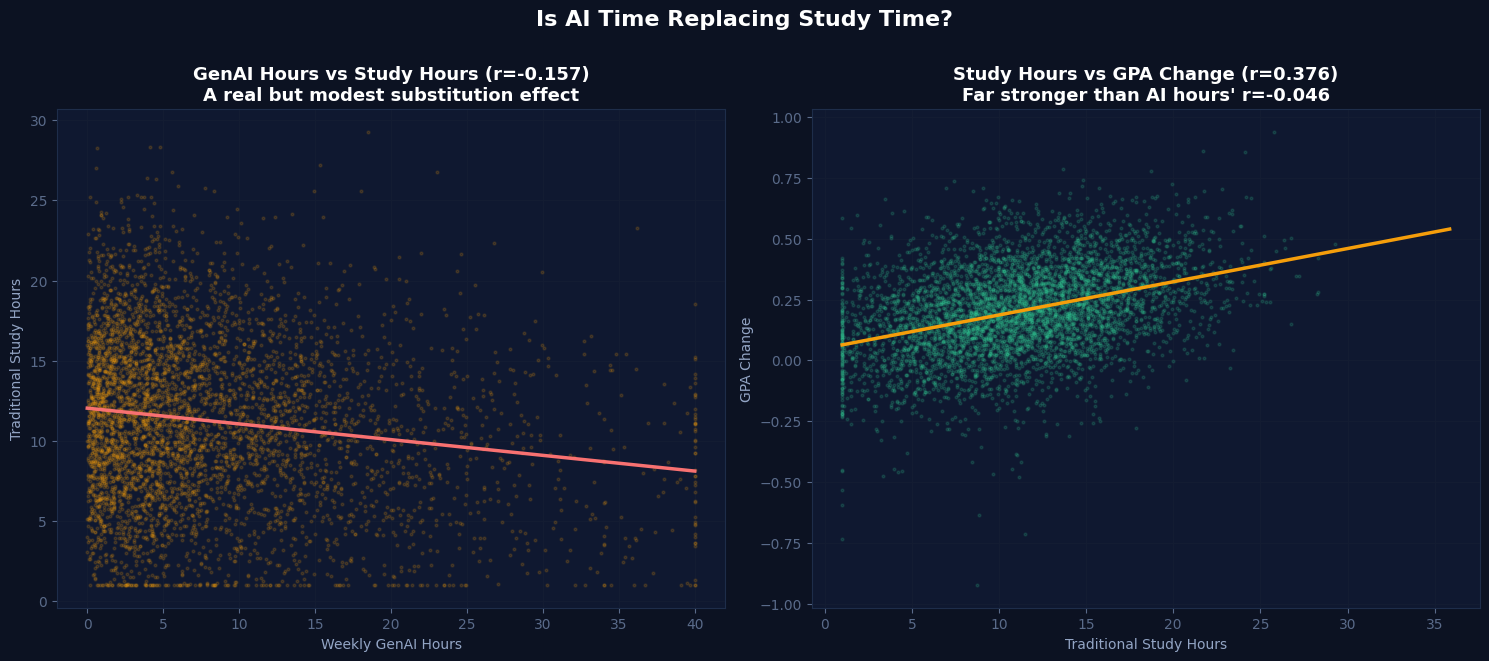

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Is AI Time Replacing Study Time?', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. AI hours vs traditional study hours scatter
ax = axes[0]
sample2 = df.sample(5000, random_state=42)
ax.scatter(sample2['Weekly_GenAI_Hours'], sample2['Traditional_Study_Hours'], color=AMBER, s=4, alpha=0.15, zorder=3)
m2, b2, r2, p2, _ = stats.linregress(df['Weekly_GenAI_Hours'], df['Traditional_Study_Hours'])
xr2 = np.linspace(0, 40, 80)
ax.plot(xr2, m2*xr2+b2, color=RED, lw=2.5, zorder=5)
ax.set_xlabel('Weekly GenAI Hours'); ax.set_ylabel('Traditional Study Hours')
ax.set_title(f'GenAI Hours vs Study Hours (r={r2:.3f})\nA real but modest substitution effect', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Study hours vs GPA change — much stronger relationship than AI hours had
ax = axes[1]
ax.scatter(sample2['Traditional_Study_Hours'], sample2['gpa_change'], color=GREEN, s=4, alpha=0.15, zorder=3)
m3, b3, r3, p3, _ = stats.linregress(df['Traditional_Study_Hours'], df['gpa_change'])
xr3 = np.linspace(df['Traditional_Study_Hours'].min(), df['Traditional_Study_Hours'].max(), 80)
ax.plot(xr3, m3*xr3+b3, color=AMBER, lw=2.5, zorder=5)
ax.set_xlabel('Traditional Study Hours'); ax.set_ylabel('GPA Change')
ax.set_title(f'Study Hours vs GPA Change (r={r3:.3f})\nFar stronger than AI hours\' r={r:.3f}', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_substitution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. The Hidden Costs — Dependency, Anxiety & Burnout <a id='7'></a>


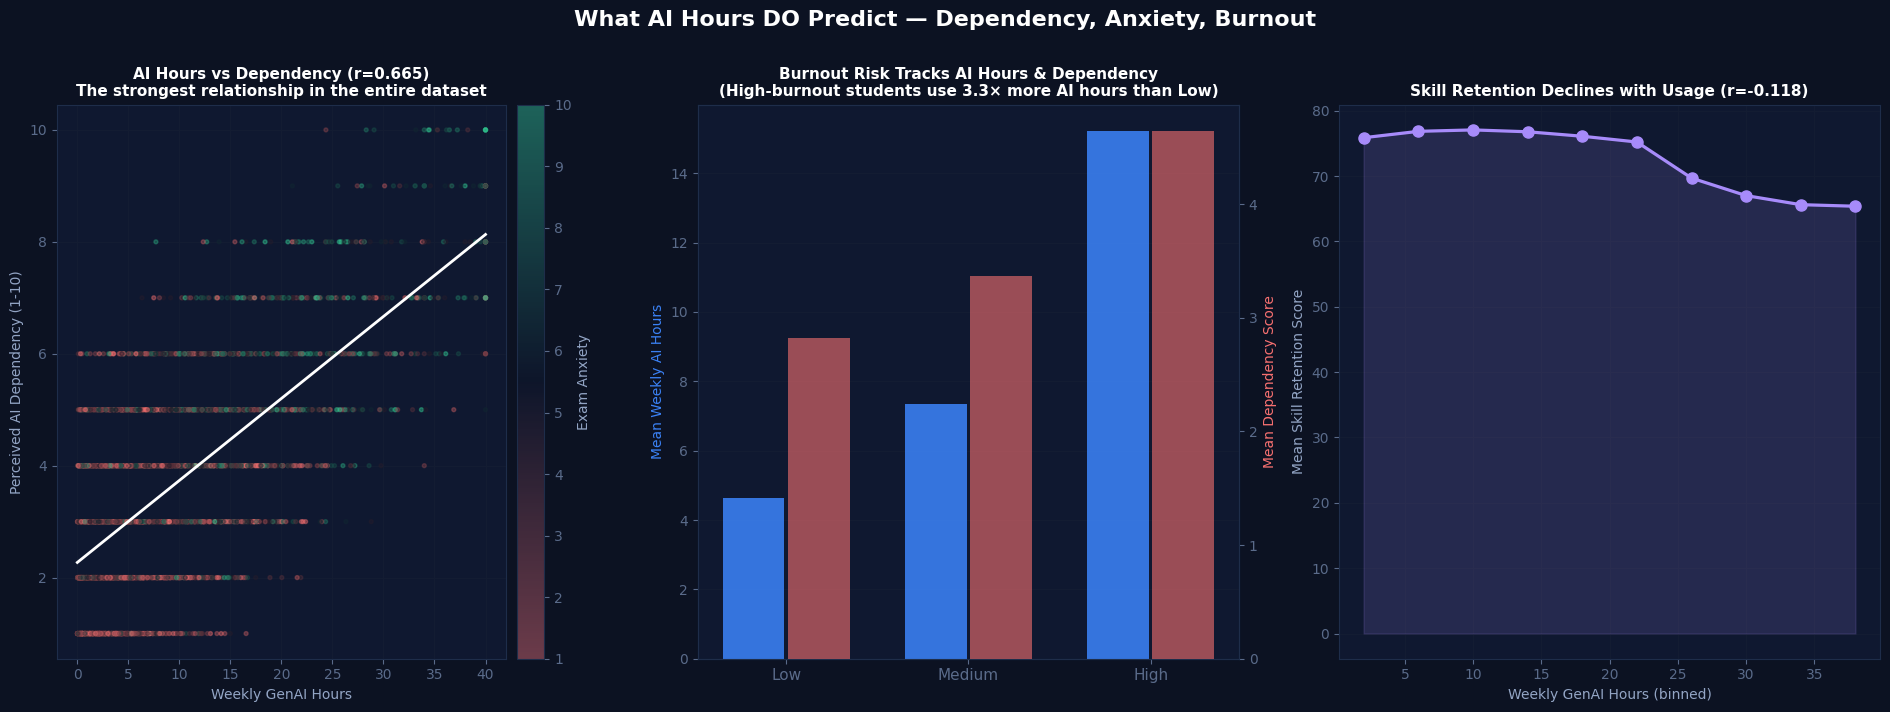

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('What AI Hours DO Predict — Dependency, Anxiety, Burnout', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. AI hours vs dependency — the strongest relationship in the dataset
ax = axes[0]
sample3 = df.sample(5000, random_state=42)
sc = ax.scatter(sample3['Weekly_GenAI_Hours'], sample3['Perceived_AI_Dependency'], c=sample3['Anxiety_Level_During_Exams'], cmap=CMAP_BA, s=8, alpha=0.4, zorder=3)
plt.colorbar(sc, ax=ax, label='Exam Anxiety', pad=0.02)
m4, b4, r4, _, _ = stats.linregress(df['Weekly_GenAI_Hours'], df['Perceived_AI_Dependency'])
xr4 = np.linspace(0, 40, 80)
ax.plot(xr4, m4*xr4+b4, color='white', lw=2, zorder=5)
ax.set_xlabel('Weekly GenAI Hours'); ax.set_ylabel('Perceived AI Dependency (1-10)')
ax.set_title(f'AI Hours vs Dependency (r={r4:.3f})\nThe strongest relationship in the entire dataset', fontweight='bold', fontsize=11)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Burnout risk breakdown
ax = axes[1]
burnout_order = ['Low','Medium','High']
burnout_hrs = df.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours'].mean().reindex(burnout_order)
burnout_dep = df.groupby('Burnout_Risk_Level')['Perceived_AI_Dependency'].mean().reindex(burnout_order)
x = np.arange(3)
ax.bar(x-0.18, burnout_hrs.values, 0.34, color=BLUE, alpha=0.88, label='Mean AI Hours', zorder=3)
ax2b = ax.twinx()
ax2b.bar(x+0.18, burnout_dep.values, 0.34, color=RED, alpha=0.6, label='Mean Dependency', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(burnout_order, fontsize=11)
ax.set_ylabel('Mean Weekly AI Hours', color=BLUE)
ax2b.set_ylabel('Mean Dependency Score', color=RED)
ax.set_title('Burnout Risk Tracks AI Hours & Dependency\n(High-burnout students use 3.3× more AI hours than Low)', fontweight='bold', fontsize=11)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Skill retention vs AI hours
ax = axes[2]
hrs_bin = pd.cut(df['Weekly_GenAI_Hours'], bins=10)
ret_by_hrs = df.groupby(hrs_bin, observed=True)['Skill_Retention_Score'].mean()
bin_centers = [interval.mid for interval in ret_by_hrs.index]
ax.plot(bin_centers, ret_by_hrs.values, 'o-', color=PURPLE, lw=2.3, ms=8, zorder=5)
ax.fill_between(bin_centers, ret_by_hrs.values, alpha=0.15, color=PURPLE)
ax.set_xlabel('Weekly GenAI Hours (binned)'); ax.set_ylabel('Mean Skill Retention Score')
ax.set_title(f'Skill Retention Declines with Usage (r={df["Weekly_GenAI_Hours"].corr(df["Skill_Retention_Score"]):.3f})', fontweight='bold', fontsize=11)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_hidden_costs.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Use Case Matters — Debugging vs Direct Answers <a id='8'></a>


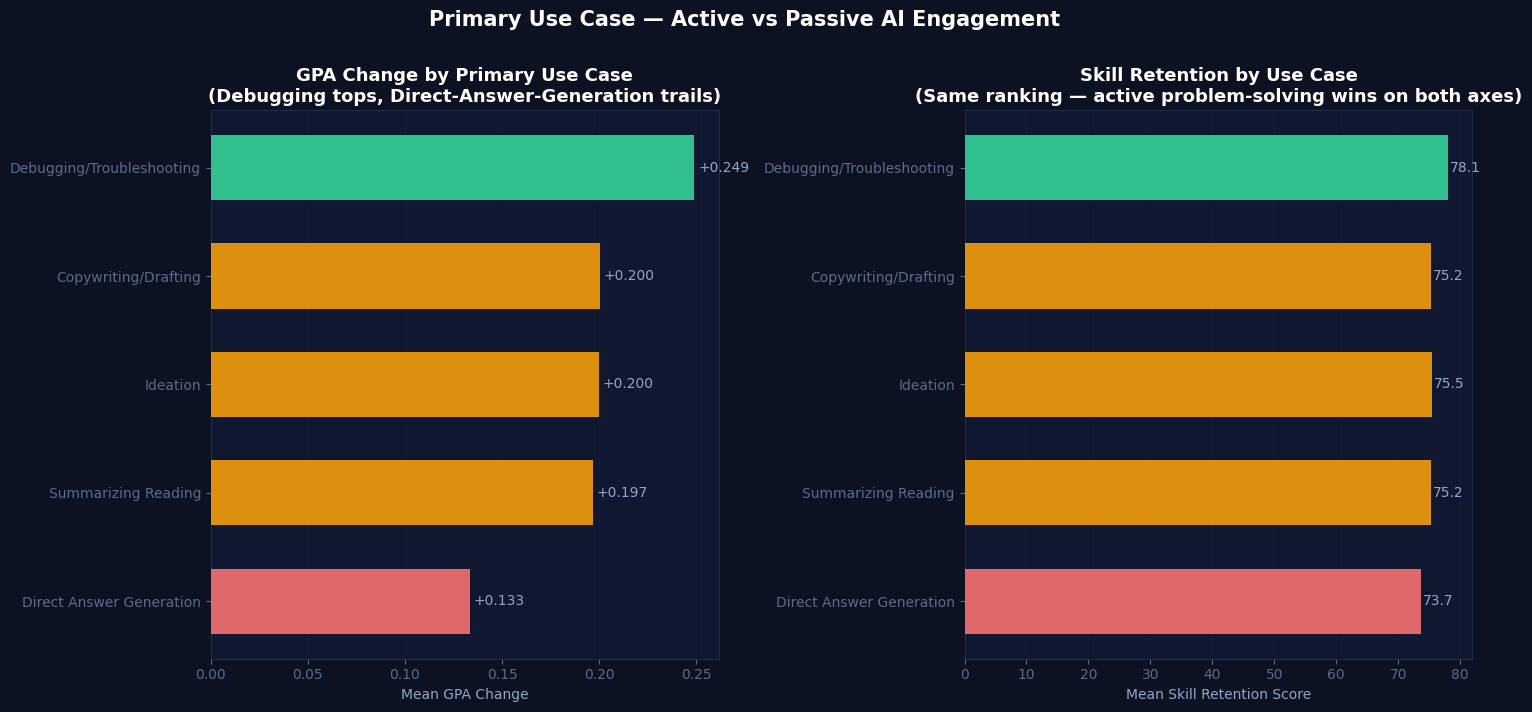

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Primary Use Case — Active vs Passive AI Engagement', fontsize=15, fontweight='bold', color='white', y=1.01)

use_order = df.groupby('Primary_Use_Case')['gpa_change'].mean().sort_values().index

# 1. GPA change by use case ranked
ax = axes[0]
uc_gpa = df.groupby('Primary_Use_Case')['gpa_change'].mean().reindex(use_order)
colors_uc = [RED if v==uc_gpa.min() else (GREEN if v==uc_gpa.max() else AMBER) for v in uc_gpa.values]
bars = ax.barh(range(len(uc_gpa)), uc_gpa.values, color=colors_uc, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(len(uc_gpa))); ax.set_yticklabels([u.replace('_',' ') for u in uc_gpa.index], fontsize=10)
ax.set_xlabel('Mean GPA Change')
ax.set_title('GPA Change by Primary Use Case\n(Debugging tops, Direct-Answer-Generation trails)', fontweight='bold')
for bar, v in zip(bars, uc_gpa.values):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{v:+.3f}', va='center', fontsize=10)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Skill retention by use case
ax = axes[1]
uc_ret = df.groupby('Primary_Use_Case')['Skill_Retention_Score'].mean().reindex(use_order)
bars2 = ax.barh(range(len(uc_ret)), uc_ret.values, color=colors_uc, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(len(uc_ret))); ax.set_yticklabels([u.replace('_',' ') for u in uc_ret.index], fontsize=10)
ax.set_xlabel('Mean Skill Retention Score')
ax.set_title('Skill Retention by Use Case\n(Same ranking — active problem-solving wins on both axes)', fontweight='bold')
for bar, v in zip(bars2, uc_ret.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}', va='center', fontsize=10)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_usecase.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Institutional Policy — Does Banning AI Help? <a id='9'></a>


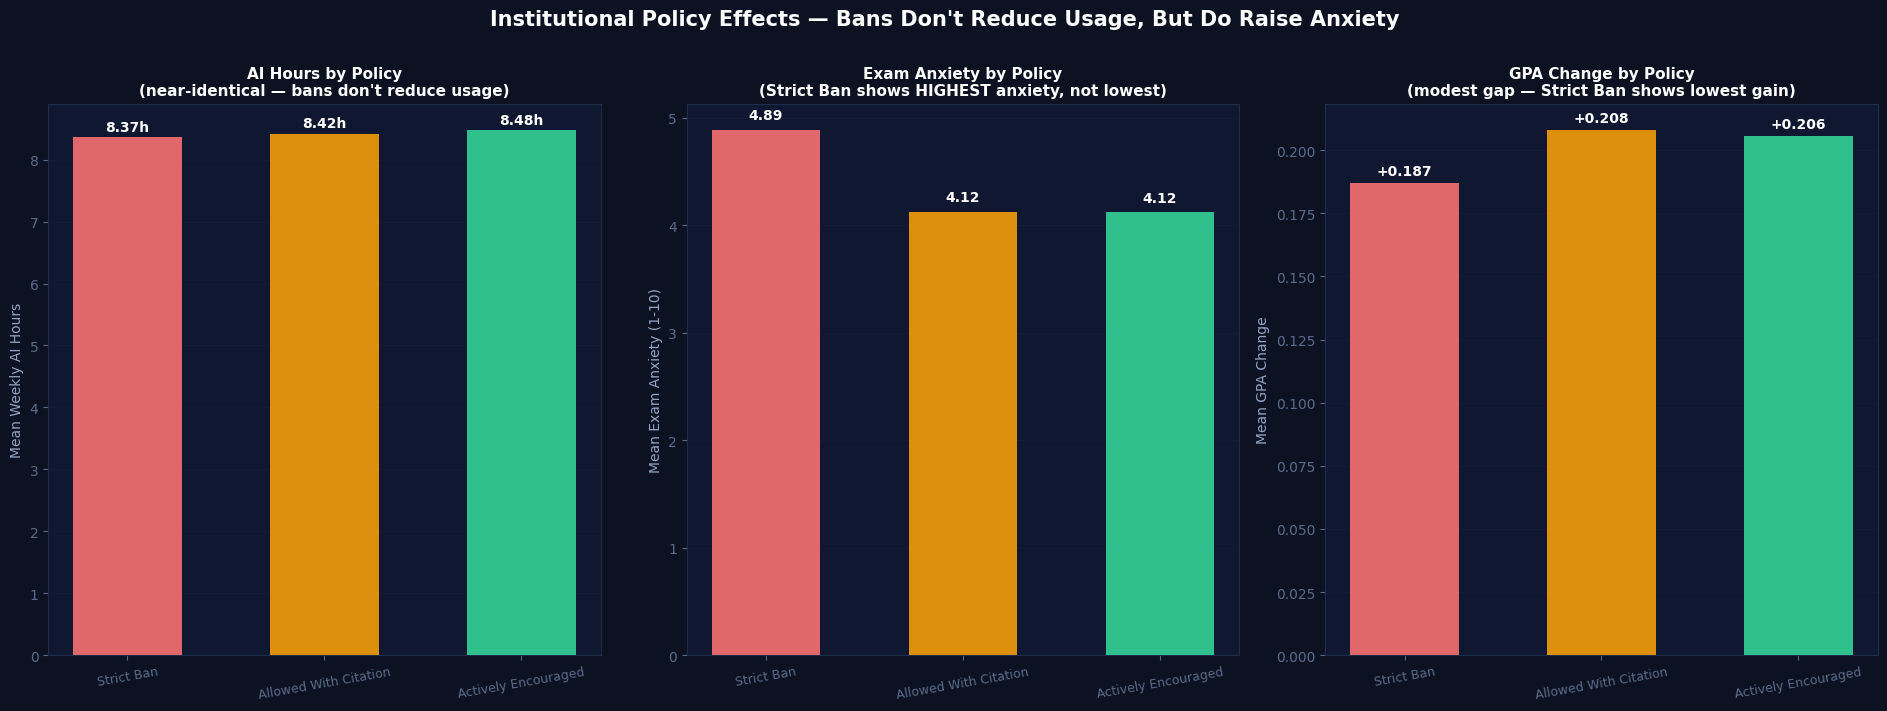

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Institutional Policy Effects — Bans Don\'t Reduce Usage, But Do Raise Anxiety',
             fontsize=15, fontweight='bold', color='white', y=1.01)

policy_order = ['Strict_Ban','Allowed_With_Citation','Actively_Encouraged']

# 1. AI hours by policy (does the ban even work?)
ax = axes[0]
pol_hrs = df.groupby('Institutional_Policy')['Weekly_GenAI_Hours'].mean().reindex(policy_order)
bars = ax.bar(range(3), pol_hrs.values, color=[POLICY_PAL[p] for p in policy_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels([p.replace('_',' ') for p in policy_order], fontsize=9, rotation=10)
ax.set_ylabel('Mean Weekly AI Hours')
ax.set_title('AI Hours by Policy\n(near-identical — bans don\'t reduce usage)', fontweight='bold', fontsize=11)
for bar, v in zip(bars, pol_hrs.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.2f}h', ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Exam anxiety by policy
ax = axes[1]
pol_anx = df.groupby('Institutional_Policy')['Anxiety_Level_During_Exams'].mean().reindex(policy_order)
bars2 = ax.bar(range(3), pol_anx.values, color=[POLICY_PAL[p] for p in policy_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels([p.replace('_',' ') for p in policy_order], fontsize=9, rotation=10)
ax.set_ylabel('Mean Exam Anxiety (1-10)')
ax.set_title('Exam Anxiety by Policy\n(Strict Ban shows HIGHEST anxiety, not lowest)', fontweight='bold', fontsize=11)
for bar, v in zip(bars2, pol_anx.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. GPA change by policy
ax = axes[2]
pol_gpa = df.groupby('Institutional_Policy')['gpa_change'].mean().reindex(policy_order)
bars3 = ax.bar(range(3), pol_gpa.values, color=[POLICY_PAL[p] for p in policy_order], width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels([p.replace('_',' ') for p in policy_order], fontsize=9, rotation=10)
ax.set_ylabel('Mean GPA Change')
ax.set_title('GPA Change by Policy\n(modest gap — Strict Ban shows lowest gain)', fontweight='bold', fontsize=11)
for bar, v in zip(bars3, pol_gpa.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_policy.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. Correlation Heatmap <a id='10'></a>


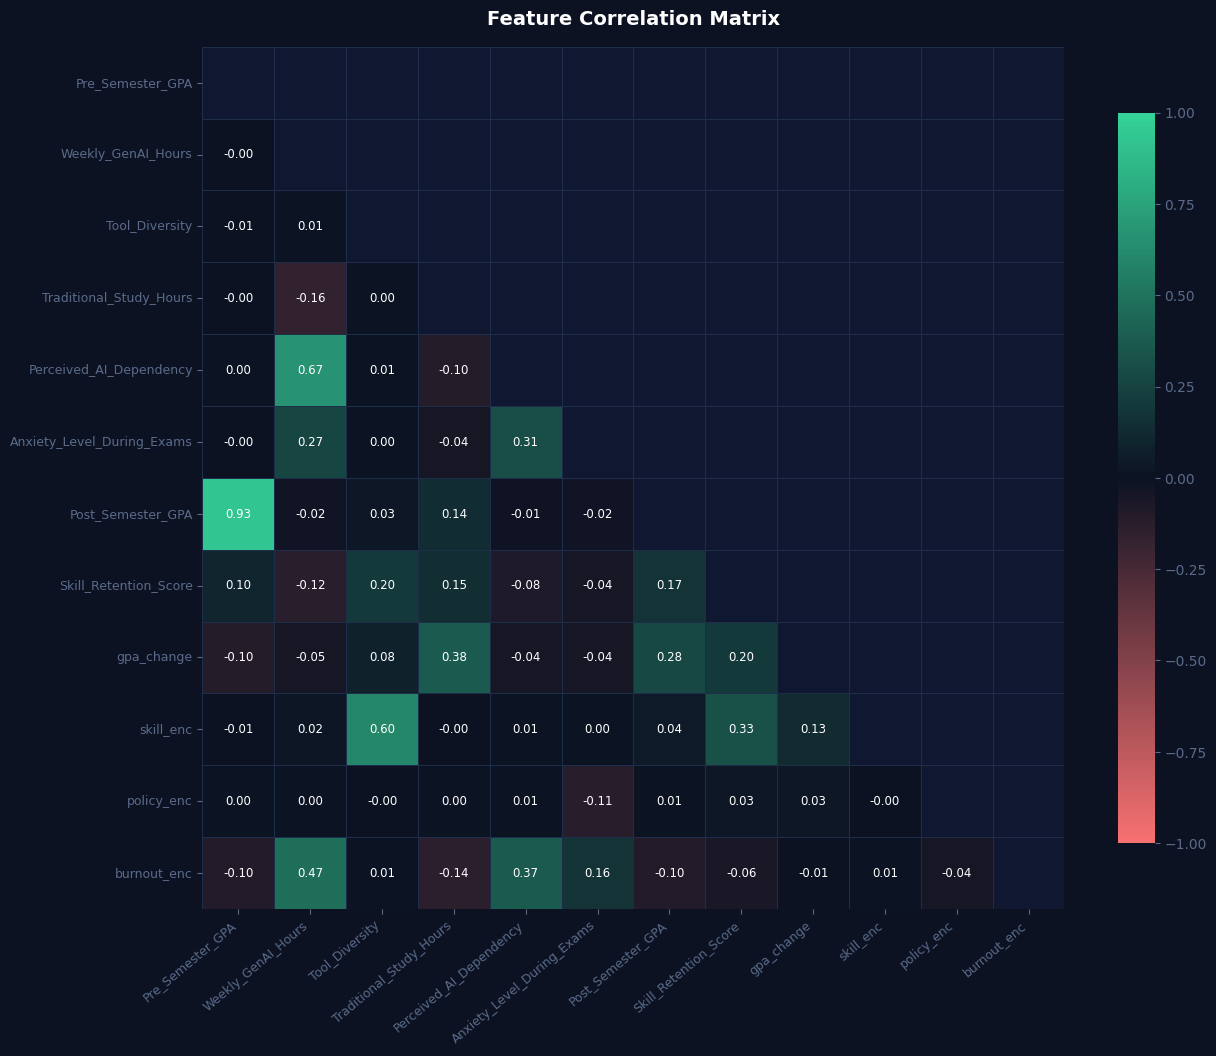

Top correlates with gpa_change:
Traditional_Study_Hours       0.376
Post_Semester_GPA             0.277
Skill_Retention_Score         0.196
skill_enc                     0.127
Pre_Semester_GPA             -0.104
Tool_Diversity                0.081
Weekly_GenAI_Hours           -0.046
Anxiety_Level_During_Exams   -0.040
Perceived_AI_Dependency      -0.039
policy_enc                    0.030
burnout_enc                  -0.007
Name: gpa_change, dtype: float64


In [12]:
corr_cols = ['Pre_Semester_GPA','Weekly_GenAI_Hours','Tool_Diversity','Traditional_Study_Hours',
             'Perceived_AI_Dependency','Anxiety_Level_During_Exams','Post_Semester_GPA',
             'Skill_Retention_Score','gpa_change','skill_enc','policy_enc','burnout_enc']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_BA, vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, linecolor=GRID, annot_kws={'size':8.5,'color':'white'},
            cbar_kws={'shrink':0.78}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('08_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top correlates with gpa_change:')
print(corr['gpa_change'].drop('gpa_change').sort_values(key=abs, ascending=False).round(3))


## 11. ML — Predicting GPA Change <a id='11'></a>


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

feat_cols = ['Pre_Semester_GPA','Weekly_GenAI_Hours','Tool_Diversity','Traditional_Study_Hours',
             'Perceived_AI_Dependency','Anxiety_Level_During_Exams','skill_enc','policy_enc','paid_enc']
X = df[feat_cols]
y = df['gpa_change']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model':model, 'preds':preds, 'r2':r2, 'mae':mae}
    print(f'{name:20s}  R²={r2:.4f}  MAE={mae:.4f}')


Linear Regression     R²=0.1705  MAE=0.1314
Random Forest         R²=0.1720  MAE=0.1302
Gradient Boosting     R²=0.2227  MAE=0.1261


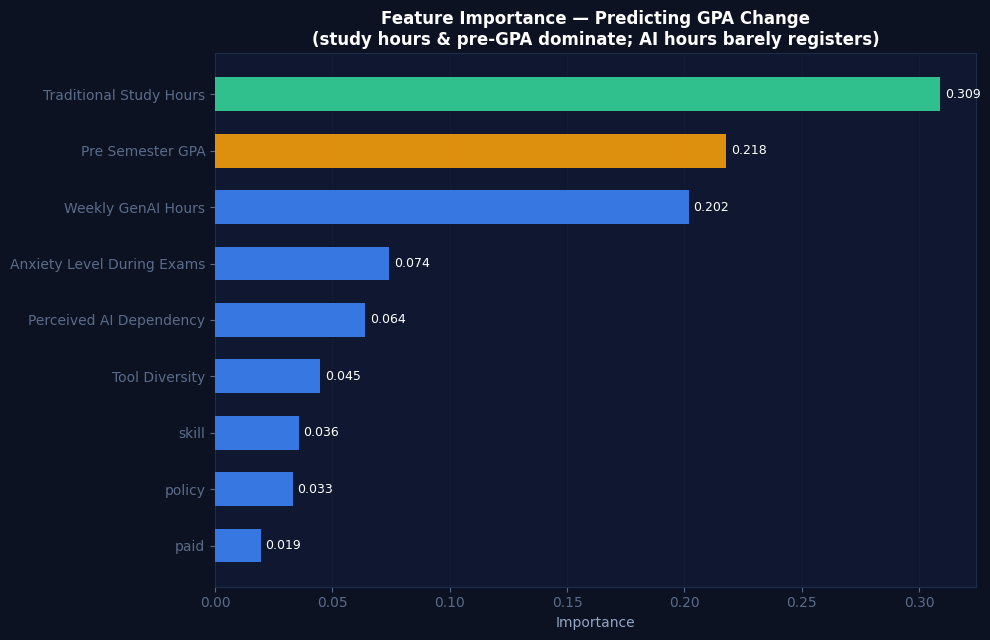

In [14]:
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(BG)

rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
colors_fi = [GREEN if f=='Traditional_Study_Hours' else (AMBER if f=='Pre_Semester_GPA' else BLUE) for f in imp.index]
ax.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(len(imp))); ax.set_yticklabels([f.replace('_enc','').replace('_',' ') for f in imp.index], fontsize=10)
ax.set_xlabel('Importance'); ax.set_title('Feature Importance — Predicting GPA Change\n(study hours & pre-GPA dominate; AI hours barely registers)', fontsize=12, fontweight='bold')
for i, v in enumerate(imp.values):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('09_ml_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 12. Key Takeaways for Policy <a id='12'></a>


<div style="background:#0c1222;border-radius:14px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #1e2d4a;">

  <h2 style="color:#fff;margin-top:0;font-size:1.3rem;">🎓 Policy-Relevant Findings — AI Student Impact Study</h2>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:18px;">
    <div style="background:#0f1830;border-radius:10px;padding:16px 18px;border-left:3px solid #f59e0b;">
      <div style="color:#f59e0b;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">📉 USAGE VOLUME ≠ ACADEMIC GAIN</div>
      <p style="color:#cbd5e1;margin:0;font-size:0.83rem;line-height:1.75;">Weekly GenAI hours correlate at just r=−0.046 with GPA change — essentially zero. Students using
      AI 20+ hours/week show no meaningful GPA advantage over those using under 5 hours/week. "More AI use"
      is not, by itself, an academic strategy.</p>
    </div>
    <div style="background:#0f1830;border-radius:10px;padding:16px 18px;border-left:3px solid #34d399;">
      <div style="color:#34d399;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🎯 SKILL AND USE CASE DO PREDICT GAINS</div>
      <p style="color:#cbd5e1;margin:0;font-size:0.83rem;line-height:1.75;">Advanced prompt engineers post +0.248 GPA change vs +0.185 for Beginners — and crucially, Advanced
      users also show <em>higher</em> skill retention (82.1 vs 71.1), not lower. Debugging/Troubleshooting
      (active, generative use) outperforms Direct Answer Generation (passive use) by +0.116 GPA points.
      <strong>How</strong> students use AI matters far more than how much.</p>
    </div>
    <div style="background:#0f1830;border-radius:10px;padding:16px 18px;border-left:3px solid #f87171;">
      <div style="color:#f87171;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">⚠️ REAL HIDDEN COSTS EXIST</div>
      <p style="color:#cbd5e1;margin:0;font-size:0.83rem;line-height:1.75;">AI hours correlate strongly with perceived dependency (r=0.665) — the single strongest relationship
      in this dataset — and meaningfully with exam anxiety (r=0.269) and reduced skill retention (r=−0.118).
      High-burnout-risk students use 3.3× more AI hours than low-risk students. These costs are real even
      though they don't show up in the GPA topline.</p>
    </div>
    <div style="background:#0f1830;border-radius:10px;padding:16px 18px;border-left:3px solid #a78bfa;">
      <div style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🚫 BANS DON'T REDUCE USAGE</div>
      <p style="color:#cbd5e1;margin:0;font-size:0.83rem;line-height:1.75;">Mean weekly AI hours are virtually identical across all three institutional policies (8.37-8.48h) —
      a Strict Ban does not meaningfully reduce actual usage. Worse, Strict-Ban students report the
      <em>highest</em> exam anxiety (4.89 vs 4.12 under permissive policies), suggesting prohibition without
      enforcement capability may add stress without changing behaviour.</p>
    </div>
    <div style="background:#0f1830;border-radius:10px;padding:16px 18px;border-left:3px solid #3b82f6;grid-column:1/-1;">
      <div style="color:#3b82f6;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">📚 STUDY HOURS STILL MATTER MOST</div>
      <p style="color:#cbd5e1;margin:0;font-size:0.83rem;line-height:1.75;">Traditional study hours correlate with GPA change at r=0.376 — over 8× stronger than GenAI hours'
      r=−0.046 — and the feature importance chart in Section 11 confirms study hours and pre-semester GPA
      dominate the predictive model, with AI usage barely registering. There is also a modest substitution
      effect (r=−0.157): heavier AI users report somewhat fewer traditional study hours, though the
      relationship is far from one-to-one.</p>
    </div>

  </div>

  <div style="background:#0f1830;border-radius:10px;padding:14px 18px;border:1px solid #1e2d4a;">
    <p style="margin:0;color:#5a6b8a;font-size:0.78rem;line-height:1.6;">
      <strong style='color:#93a5c5;'>⚠️ Caveats:</strong> This is self-reported survey data — perceived dependency, anxiety, and burnout risk
      are subjective measures that may not align perfectly with clinical or behavioural definitions. Correlational
      findings cannot establish that AI usage <em>causes</em> dependency or anxiety; students prone to either may
      simply use AI more. Policy recommendations should be validated with longitudinal or experimental designs
      before institutional rollout.
    </p>
  </div>

  <div style="margin-top:14px;text-align:right;color:#1e2d4a;font-size:0.72rem;">Author: Muhammad Aamir · 50,000 Students · Kaggle Notebook</div>

</div>
